In [32]:
"""
Plot T, S and SSH from CROCO at a target z-level.
Uses xarray to open the file and xgcm.Grid.transform()
to interpolate from terrain-following sigma coords to a fixed z.

Install: pip install xarray xgcm matplotlib netcdf4
"""

import numpy as np
import xarray as xr
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xgcm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import OSM

# ── Configuration ──────────────────────────────────────────────────────────────
CROCO_FILE = "model-runs-main/Canary_12/CROCO_FILES/croco_his.nc"
TARGET_Z      =  0.0   # metres  (0 = surface)
QUIVER_STRIDE =  3     # one arrow every N grid points (increase to thin out)
 
# Point of interest — nearest grid cell will be found automatically
LON_PT = -18.0
LAT_PT =  19.5

# high resolution backgrounf image
da = rioxarray.open_rasterio('/home/fernand/Images/nh/HYP_HR_SR_OB_DR/HYP_HR_SR_OB_DR.tif')


In [33]:
# ── Helper: sigma → physical z ────────────────────────────────────────────────
def compute_z_rho(h, zeta, hc, Cs_rho, s_rho, vtransform):
    N = len(Cs_rho)
    z = np.empty((N, *h.shape))
    if vtransform == 1:
        for k in range(N):
            z0   = hc * s_rho[k] + (h - hc) * Cs_rho[k]
            z[k] = z0 + zeta * (1.0 + z0 / h)
    else:
        for k in range(N):
            z0   = (hc * s_rho[k] + h * Cs_rho[k]) / (hc + h)
            z[k] = zeta + (zeta + h) * z0
    return z
 
# ── Helper: vectorised isoslice ───────────────────────────────────────────────
def isoslice(var, z, target_z):
    above = np.sum(z < target_z, axis=0).clip(0, z.shape[0] - 2)
    idx   = np.indices(var.shape[1:])
    z0, z1 = z[above, idx[0], idx[1]],    z[above+1, idx[0], idx[1]]
    v0, v1 = var[above, idx[0], idx[1]], var[above+1, idx[0], idx[1]]
    dz = np.where(z1 - z0 == 0, np.nan, z1 - z0)
    return np.ma.masked_invalid(v0 + (target_z - z0) / dz * (v1 - v0))
 

In [34]:
# ── Load static fields ─────────────────────────────────────────────────────────
nc = Dataset(CROCO_FILE, "r")
 
lon        = nc.variables["lon_rho"][:]
lat        = nc.variables["lat_rho"][:]
mask       = nc.variables["mask_rho"][:]
h          = np.array(nc.variables["h"][:],      dtype=float)
hc         = float(nc.variables["hc"][:])
Cs_rho     = np.array(nc.variables["Cs_rho"][:], dtype=float)
s_rho      = np.array(nc.variables["s_rho"][:],  dtype=float)
vtransform = int(nc.variables["Vtransform"][:])
times      = nc.variables["scrum_time"][:]
n_times    = len(times)
t_days     = times / 86400.0
 
land = mask == 0
h[land] = np.nan
 
# ── Nearest grid point ────────────────────────────────────────────────────────
dist       = (lon - LON_PT)**2 + (lat - LAT_PT)**2
j_pt, i_pt = np.unravel_index(np.argmin(dist), dist.shape)
lon_actual = lon[j_pt, i_pt]
lat_actual = lat[j_pt, i_pt]
print(f"Selected point: ({LON_PT}°E, {LAT_PT}°N) → "
      f"nearest grid cell ({lon_actual:.3f}°E, {lat_actual:.3f}°N) "
      f"[j={j_pt}, i={i_pt}]")
 
# ── Pre-compute fields for all time steps ─────────────────────────────────────
T_all, S_all, SSH_all = [], [], []
U_all, V_all          = [], []       # surface velocity on rho grid
T_ts,  S_ts,  SSH_ts  = [], [], []
 
for t in range(n_times):
    zeta = np.array(nc.variables["zeta"][t,    :, :], dtype=float)
    T3d  = np.array(nc.variables["temp"][t, :, :, :], dtype=float)
    S3d  = np.array(nc.variables["salt"][t, :, :, :], dtype=float)
    u3d  = np.array(nc.variables["u"]   [t, :, :, :], dtype=float)  # (N, eta_rho, xi_u)
    v3d  = np.array(nc.variables["v"]   [t, :, :, :], dtype=float)  # (N, eta_v,  xi_rho)

    for arr in (zeta, T3d, S3d, u3d, v3d):
        arr[np.abs(arr) > 1e10] = np.nan
    zeta[land] = np.nan

    z3d = compute_z_rho(h, zeta, hc, Cs_rho, s_rho, vtransform)

    T_map   = isoslice(T3d, z3d, TARGET_Z)
    S_map   = isoslice(S3d, z3d, TARGET_Z)
    SSH_map = np.ma.masked_where(land, zeta)

    # Surface velocity: top sigma level (k=-1) interpolated to rho grid
    # u: (eta_rho, xi_u) with xi_u = xi_rho-1 → (eta_rho, xi_rho)
    # v: (eta_v,  xi_rho) with eta_v = eta_rho-1 → (eta_rho, xi_rho)
    u_surf = u3d[-1, :, :]                                  # (eta_rho, xi_u)
    v_surf = v3d[-1, :, :]                                  # (eta_v,   xi_rho)
    nj, ni = land.shape

    u_rho          = np.full((nj, ni), np.nan)
    u_rho[:, 1:-1] = 0.5 * (u_surf[:, :-1] + u_surf[:, 1:])  # interior
    u_rho[:, 0]    = u_surf[:, 0]                              # west edge
    u_rho[:, -1]   = u_surf[:, -1]                            # east edge

    v_rho          = np.full((nj, ni), np.nan)
    v_rho[1:-1, :] = 0.5 * (v_surf[:-1, :] + v_surf[1:, :])  # interior
    v_rho[0, :]    = v_surf[0, :]                              # south edge
    v_rho[-1, :]   = v_surf[-1, :]                            # north edge

    u_rho = np.ma.masked_where(land, u_rho)
    v_rho = np.ma.masked_where(land, v_rho)

    T_all.append(T_map);  S_all.append(S_map);  SSH_all.append(SSH_map)
    U_all.append(u_rho);  V_all.append(v_rho)

    T_ts  .append(float(T_map  [j_pt, i_pt]))
    S_ts  .append(float(S_map  [j_pt, i_pt]))
    SSH_ts.append(float(SSH_map[j_pt, i_pt]))

nc.close()



Selected point: (-18.0°E, 19.5°N) → nearest grid cell (-18.008°E, 19.494°N) [j=67, i=49]


In [35]:
# ── Shared colour limits ───────────────────────────────────────────────────────
def robust_lim(arrays):
    data = np.ma.concatenate([a.compressed() for a in arrays])
    return np.nanpercentile(data, 2), np.nanpercentile(data, 98)
 
T_lim   = robust_lim(T_all)
S_lim   = robust_lim(S_all)
SSH_lim = robust_lim(SSH_all)
 
# ── Quiver subsampling indices ─────────────────────────────────────────────────
s = QUIVER_STRIDE
q_lon = lon [::s, ::s]
q_lat = lat [::s, ::s]
 
# ── Cartopy features ───────────────────────────────────────────────────────────
PROJ   =  ccrs.PlateCarree() # OSM().crs 
extent = [np.nanmin(lon), np.nanmax(lon), np.nanmin(lat), np.nanmax(lat)]
#
tiler = OSM()

da_reproj = da.rio.reproject(PROJ.proj4_init)
img_reproj = da_reproj.values

land_patch = cfeature.NaturalEarthFeature(
    "physical", "land", "10m", facecolor="lightgrey", edgecolor="none", zorder=3)
coastline  = cfeature.NaturalEarthFeature(
    "physical", "coastline", "10m", facecolor="none",
    edgecolor="black", linewidth=0.6, zorder=4)
borders    = cfeature.NaturalEarthFeature(
    "cultural", "admin_0_countries", "10m", facecolor="none",
    edgecolor="dimgrey", linewidth=0.4, zorder=4)

relief = cfeature.NaturalEarthFeature(
    category='physical', name='shaded_relief',scale='110m',
    facecolor='none',  zorder=4)


/home/fernand/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [36]:
# ── Domain extent ──────────────────────────────────────────────────────────────
lon_min, lon_max = np.nanmin(lon), np.nanmax(lon)
lat_min, lat_max = np.nanmin(lat), np.nanmax(lat)
extent = [lon_min, lon_max, lat_min, lat_max]
 
time_day = ["init_01-01","prev_02-01\n06h00","prev_02-01\n12h00","prev_02-01\n18h00","prev_03-01\n00h00"]

<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not 

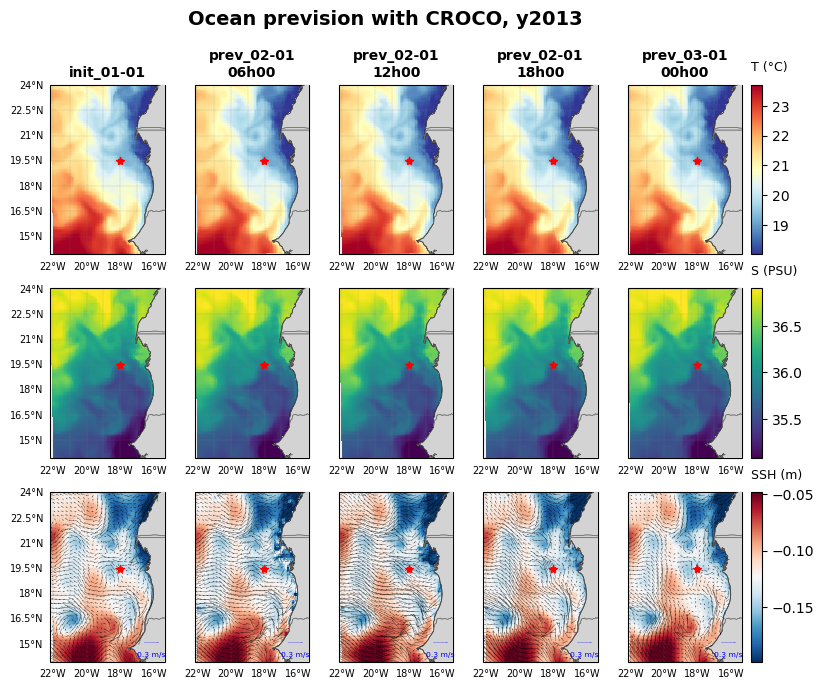

In [38]:
rows = [
    ("T",   T_all,   "RdYlBu_r", T_lim,   "T (°C)", False),
    ("S",   S_all,   "viridis",  S_lim,   "S (PSU)", False),
    ("SSH", SSH_all, "RdBu_r",   SSH_lim, "SSH (m)", True),
]

fig1, axes = plt.subplots(
    3, n_times,
    figsize=(9, 7.5),
    subplot_kw={"projection": PROJ},)
    #gridspec_kw={"wspace": 0.15, "hspace": 0.25},)
 
for row_idx, (var_name, data_list, cmap, (vmin, vmax), cbar_label, add_quiver) in enumerate(rows):
    for col_idx, data in enumerate(data_list):
        ax = axes[row_idx, col_idx]
        ax.set_extent(extent, crs=PROJ) #ccrs.PlateCarree()) 
        ax.add_image(tiler,6)
        ax.pcolormesh(lon, lat, data, cmap=cmap, vmin=vmin, vmax=vmax,
                      shading="auto", transform=PROJ, zorder=1)
 
        # Quivers on SSH row only
        if add_quiver:
            q_u = U_all[col_idx][::s, ::s]
            q_v = V_all[col_idx][::s, ::s]
            qv  = ax.quiver(
                q_lon, q_lat, q_u, q_v,
                transform   = PROJ,
                scale       = 2,       
                scale_units = "inches",
                width       = 0.003,
                color       = "k",
                alpha       = 0.8,
                zorder      = 5,
            )
            qk = ax.quiverkey(qv, X=0.88, Y=0.12, U=0.3,
                         label="0.3 m/s", labelpos="S", color='b', labelcolor='b',
                         fontproperties={"size": 5.5}, zorder=6)
                         
        ax.add_feature(land_patch)
        #ax.stock_img()
        ax.add_feature(coastline)
        ax.add_feature(borders) 
        
        ax.plot(lon_actual, lat_actual, marker="*", color="red",
                markersize=6, transform=PROJ, zorder=7)
 
        gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                          color="grey", alpha=0.5, linestyle="--", zorder=5)
        gl.top_labels    = False
        gl.right_labels  = False
        gl.left_labels   = (col_idx == 0)
        gl.bottom_labels# = (row_idx == 2)
        gl.xlabel_style  = {"size": 7}
        gl.ylabel_style  = {"size": 7}
 
        if row_idx == 0:
            ax.set_title(time_day[col_idx], #f"t = {t_days:.2f} days", fontsize=10, fontweight="bold")
                         fontsize=10, fontweight="bold")
        
        """if col_idx == 0:
            ax.text(-0.18, 0.5, var_name, transform=ax.transAxes,
                    fontsize=12, fontweight="bold", va="center", rotation=90)"""
         
        ax.stock_img()
        
    # Shared colorbar per row
    # Shared colorbar per row
    pos  = axes[row_idx, -1].get_position()
    c_ax = fig1.add_axes([pos.x1 + 0.01, pos.y0, 0.012, pos.height])
    sm   = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig1.colorbar(sm, cax=c_ax)
    cbar.ax.set_title(cbar_label, loc='left',fontsize=9, pad=10)  # title instead of label
    
fig1.suptitle("Ocean prevision with CROCO, y2013",
    fontsize=14, fontweight="bold")

fig1.savefig("croco_maps.png", dpi=300, bbox_inches="tight")
 

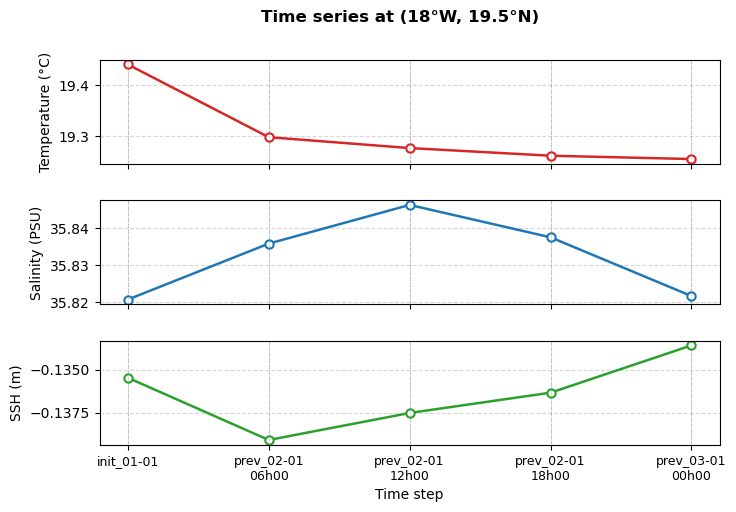

Saved → croco_maps.png  and  croco_timeseries.png


In [69]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — time series at selected point
# ══════════════════════════════════════════════════════════════════════════════
fig2, axs = plt.subplots(3, 1, figsize=(8, 5), sharex=True,
                         gridspec_kw={"hspace": 0.35})
 
ts_panels = [
    (axs[0], T_ts,   "tab:red",   "Temperature (°C)"),
    (axs[1], S_ts,   "tab:blue",  "Salinity (PSU)"),
    (axs[2], SSH_ts, "tab:green", "SSH (m)"),
]
 
for ax, values, color, ylabel in ts_panels:
    ax.plot(t_days, values, marker="o", color=color,
            linewidth=1.8, markersize=6, markerfacecolor="white",
            markeredgewidth=1.5)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    for t in t_days:
        ax.axvline(t, color="grey", linewidth=0.4, linestyle=":")
 
axs[-1].set_xlabel("Time (days)", fontsize=10)

# Text labels for each time step on the x-axis
t_labels = ["init_01-01","prev_02-01\n06h00","prev_02-01\n12h00","prev_02-01\n18h00","prev_03-01\n00h00"]
axs[-1].set_xticks(t_days)
axs[-1].set_xticklabels(t_labels, fontsize=9)
axs[-1].set_xlabel("Time step", fontsize=10)
 

fig2.suptitle(
    f"Time series at (18°W, 19.5°N)",
    fontsize=12, fontweight="bold"
)
fig2.savefig("croco_timeseries.png", dpi=150, bbox_inches="tight")
 
plt.show()
print("Saved → croco_maps.png  and  croco_timeseries.png")


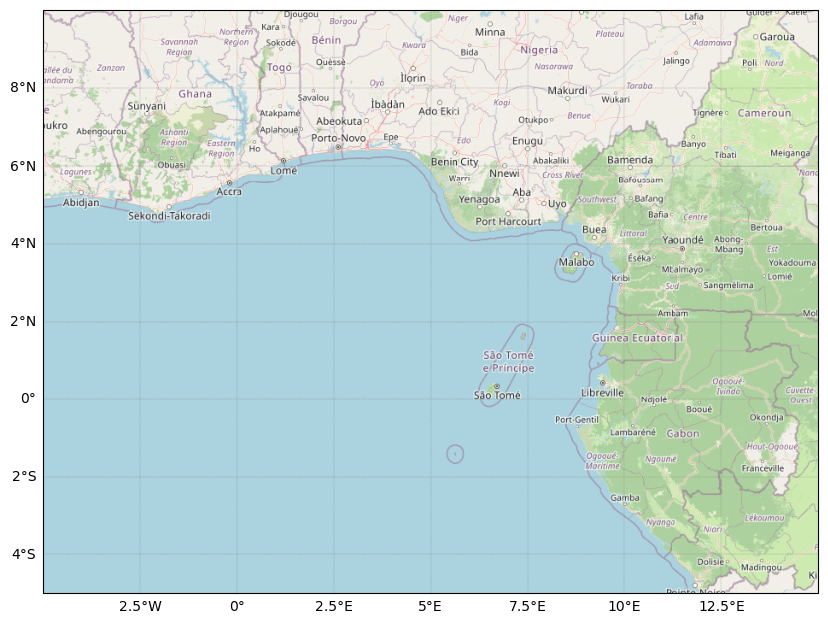

In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.io.img_tiles import OSM

tiler = OSM()
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=tiler.crs)

# Set extent (longitude, latitude) in PlateCarree
ax.set_extent([-5, 15, -5, 10], crs=ccrs.PlateCarree())

# Correct: zoom as positional argument
ax.add_image(tiler, 6)

gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                          color="grey", alpha=0.75, linestyle="--", zorder=5)
gl.top_labels    = False
gl.right_labels  = False
gl.left_labels 
gl.bottom_labels
gl.xlabel_style  = {"size": 10}
gl.ylabel_style  = {"size": 10}
 
plt.show()

In [1]:
import os
from datetime import datetime, timedelta
import copernicusmarine
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION (use environment variables for credentials) ---
username = os.environ.get("CMEMS_USERNAME", "your_username")
password = os.environ.get("CMEMS_PASSWORD", "your_password")

# Region and time
start_date = datetime(2013, 1, 1)
end_date   = datetime(2013, 1, 3)   # inclusive
lon_min, lon_max = -23.0, -15.0
lat_min, lat_max = 12.0, 25.0
depth_level = 0.49402499198913574   # single near-surface level

# Output directory
output_dir = "/home/fernand/Documents/OPERA/SEA-FORWARD/model_run/model-runs-main/Canary_12/CROCO_FILES"
os.makedirs(output_dir, exist_ok=True)

# Variables needed (add uo, vo if you want currents for plotting)
variables = ["thetao", "zos"]   # add "uo", "vo" if required

# --- Download the whole period in one request (much faster) ---
# Note: some datasets require start_datetime != end_datetime for a range.
# Here we use a single file for 2013-01-01 to 2013-01-03.
output_filename = "cmems_20130101_20130103.nc"

try:
    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
        variables=variables,
        minimum_longitude=lon_min,
        maximum_longitude=lon_max,
        minimum_latitude=lat_min,
        maximum_latitude=lat_max,
        start_datetime=start_date.strftime("%Y-%m-%d"),
        end_datetime=end_date.strftime("%Y-%m-%d"),
        minimum_depth=depth_level,
        maximum_depth=depth_level,
        output_filename=output_filename,
        output_directory=output_dir,
    )
    print(f"Downloaded {output_filename} successfully.")
except Exception as e:
    print(f"Failed: {e}")



INFO - 2026-05-26T13:12:44Z - Selected dataset version: "202311"
INFO - 2026-05-26T13:12:44Z - Selected dataset part: "default"


Failed: Invalid version: 'unknown'
